# Classificazione Heart Disease — UCI Repository

**Dataset:** Heart Disease (Cleveland) — UCI ML Repository (ID: 45)  
**Corso:** Apprendimento Automatico e Apprendimento Profondo

Il progetto affronta un task di classificazione binaria: stabilire se un paziente
presenta una malattia cardiaca sulla base di parametri clinici.

**Struttura del notebook:**
1. Caricamento e preparazione del dataset
2. Analisi PCA delle feature
3. Tre algoritmi di classificazione: Logistic Regression, Random Forest, SVM
4. Metriche di valutazione: Precision, Recall, F1, Accuracy, ROC AUC
5. Matrice di confusione e curva ROC
6. Spiegabilita con SHAP applicata al modello Random Forest

## Dipendenze

Decommentare la riga seguente solo se le librerie non sono gia presenti.

In [1]:
 !pip install ucimlrepo shap scikit-learn matplotlib seaborn pandas numpy

## Import delle librerie

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

import shap

print("Librerie caricate correttamente.")

Librerie caricate correttamente.


## Caricamento e preparazione del dataset

Il dataset Heart Disease (Cleveland) contiene parametri clinici di 303 pazienti.
Il campo target va da 0 a 4: 0 indica assenza di malattia, 1-4 la sua presenza.
Viene trasformato in classificazione binaria: 0 = sano, 1 = malattia cardiaca.

In [3]:
# Caricamento dal repository UCI tramite la libreria ucimlrepo
raw = fetch_ucirepo(id=45)
X = raw.data.features.copy()
y_raw = raw.data.targets.copy()

# Binarizzazione del target: 0 = sano, 1-4 = malattia cardiaca
y = y_raw.iloc[:, 0].apply(lambda v: 0 if v == 0 else 1)

print("Dataset caricato.")
print(f"Dimensioni originali: {X.shape[0]} campioni, {X.shape[1]} feature")
print(f"\nDistribuzione delle classi:")
print(y.value_counts())
print(f"\nFeature: {list(X.columns)}")

Dataset caricato.
Dimensioni originali: 303 campioni, 13 feature

Distribuzione delle classi:
num
0    164
1    139
Name: count, dtype: int64

Feature: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [4]:
# Le colonne ca e thal contengono alcune righe con valori mancanti
print("Valori mancanti per feature:")
print(X.isnull().sum())

# Rimozione delle righe incomplete
valid = X.notnull().all(axis=1)
X = X[valid].reset_index(drop=True)
y = y[valid].reset_index(drop=True)

print(f"\nDimensioni dopo la pulizia: {X.shape}")

Valori mancanti per feature:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Dimensioni dopo la pulizia: (297, 13)


In [5]:
X.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.54,9.05,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,297.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,297.0,131.69,17.76,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.35,52.00,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.14,0.35,0.0,0.0,0.0,0.0,1.0
restecg,297.0,1.00,0.99,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.60,22.94,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.06,1.17,0.0,0.0,0.8,1.6,6.2


## Suddivisione train/test e standardizzazione

In [6]:
# Suddivisione 70/30 con stratificazione sulle classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} campioni")
print(f"Test set:     {X_test.shape[0]} campioni")

# Standardizzazione: fit solo sul training set per evitare data leakage
scaler = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X.columns
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test), columns=X.columns
)

Training set: 207 campioni
Test set:     90 campioni


## Task 1 — Analisi PCA

La PCA trasforma le feature originali in componenti non correlate ordinate per
quantita di varianza spiegata. Prima si analizza quante componenti sono necessarie
per coprire il 90% della varianza, poi si visualizza la proiezione sui primi due assi.

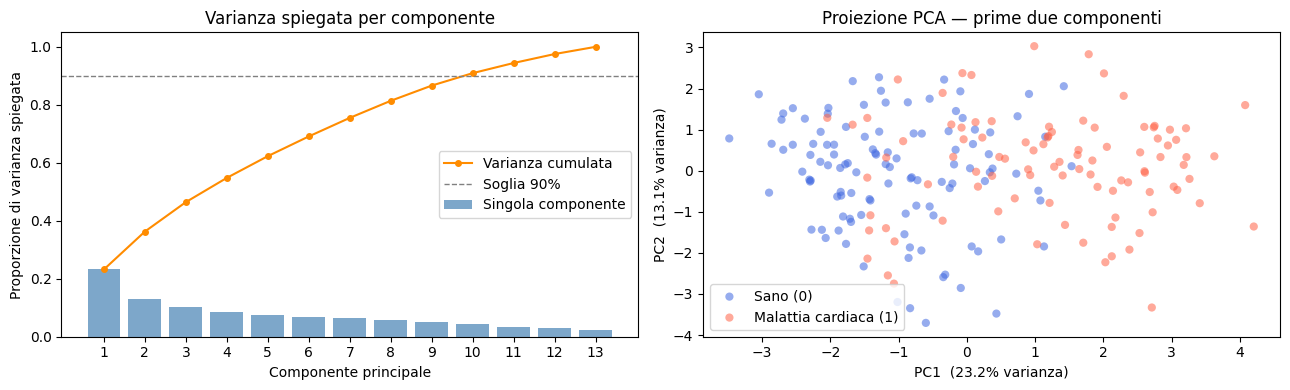

Componenti necessarie per il 90% della varianza: 10 su 13
Le prime 2 componenti spiegano il 36.3% della varianza totale.


In [7]:
# PCA completa per analizzare la varianza spiegata
pca_full = PCA()
pca_full.fit(X_train_sc)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot con varianza cumulata
components = range(1, len(explained) + 1)
axes[0].bar(components, explained, color="steelblue", alpha=0.7, label="Singola componente")
axes[0].plot(components, cumulative, color="darkorange", marker="o",
             markersize=4, linewidth=1.5, label="Varianza cumulata")
axes[0].axhline(y=0.90, color="gray", linestyle="--", linewidth=1, label="Soglia 90%")
axes[0].set_xlabel("Componente principale")
axes[0].set_ylabel("Proporzione di varianza spiegata")
axes[0].set_title("Varianza spiegata per componente")
axes[0].set_xticks(list(components))
axes[0].legend()

# Proiezione sulle prime due componenti principali
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_train_sc)

class_colors = {0: "royalblue", 1: "tomato"}
class_labels = {0: "Sano (0)", 1: "Malattia cardiaca (1)"}

for cls in [0, 1]:
    mask = y_train.values == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=class_colors[cls], label=class_labels[cls],
                    alpha=0.55, s=35, edgecolors="none")

axes[1].set_xlabel(f"PC1  ({explained[0]*100:.1f}% varianza)")
axes[1].set_ylabel(f"PC2  ({explained[1]*100:.1f}% varianza)")
axes[1].set_title("Proiezione PCA — prime due componenti")
axes[1].legend()

plt.tight_layout()
plt.savefig("pca_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

n90 = int(np.argmax(cumulative >= 0.90)) + 1
print(f"Componenti necessarie per il 90% della varianza: {n90} su {X.shape[1]}")
print(f"Le prime 2 componenti spiegano il {cumulative[1]*100:.1f}% della varianza totale.")

## Task 2 — Algoritmi di classificazione

Vengono addestrati tre classificatori sul training set standardizzato:
- **Logistic Regression**: modello lineare, utile come punto di riferimento
- **Random Forest**: ensemble di alberi decisionali, robusto e interpretabile
- **SVM con kernel RBF**: efficace con relazioni non lineari tra le feature

In [8]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model = SVC(kernel="rbf", probability=True, random_state=42)

lr_model.fit(X_train_sc, y_train)
rf_model.fit(X_train_sc, y_train)
svm_model.fit(X_train_sc, y_train)

print("Addestramento completato per tutti e tre i modelli.")

Addestramento completato per tutti e tre i modelli.


## Task 3 — Metriche di valutazione

Le metriche vengono calcolate sul test set per ogni classificatore.
- **Precision**: dei campioni classificati come positivi, quanti lo sono davvero
- **Recall**: dei campioni positivi reali, quanti vengono identificati correttamente
- **F1-score**: media armonica di Precision e Recall
- **Accuracy**: percentuale totale di predizioni corrette
- **ROC AUC**: area sotto la curva ROC, misura la capacita discriminante del modello

In [9]:
classifiers = {
    "Logistic Regression": lr_model,
    "Random Forest":       rf_model,
    "SVM":                 svm_model,
}

scores = {}
for name, model in classifiers.items():
    preds = model.predict(X_test_sc)
    probs = model.predict_proba(X_test_sc)[:, 1]

    scores[name] = {
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall":    round(recall_score(y_test, preds), 4),
        "F1-score":  round(f1_score(y_test, preds), 4),
        "Accuracy":  round(accuracy_score(y_test, preds), 4),
        "ROC AUC":   round(roc_auc_score(y_test, probs), 4),
    }

df_scores = pd.DataFrame(scores).T
print(df_scores.to_string())

                     Precision  Recall  F1-score  Accuracy  ROC AUC
Logistic Regression     0.8684  0.7857    0.8250    0.8444   0.9439
Random Forest           0.8718  0.8095    0.8395    0.8556   0.9293
SVM                     0.8857  0.7381    0.8052    0.8333   0.9340


## Task 4 — Matrice di confusione e curva ROC

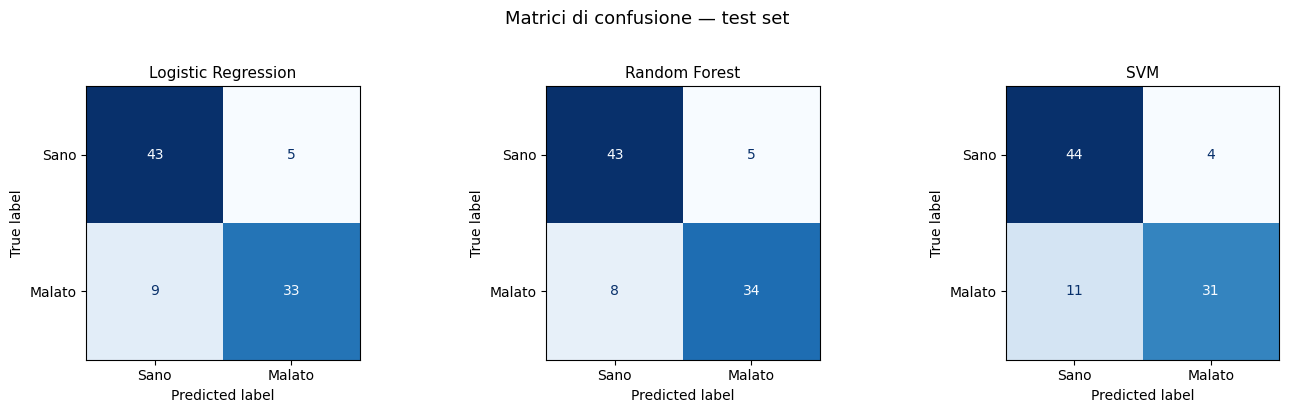

In [10]:
# Matrici di confusione affiancate per i tre modelli
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, classifiers.items()):
    preds = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sano", "Malato"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11)

plt.suptitle("Matrici di confusione — test set", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

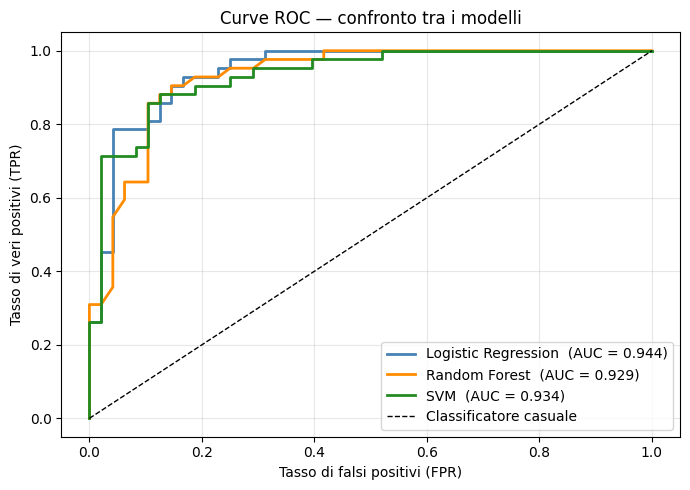

In [11]:
# Curve ROC sovrapposte per confrontare i tre modelli
fig, ax = plt.subplots(figsize=(7, 5))

palette = ["steelblue", "darkorange", "forestgreen"]
for (name, model), color in zip(classifiers.items(), palette):
    probs = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name}  (AUC = {roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Classificatore casuale")
ax.set_xlabel("Tasso di falsi positivi (FPR)")
ax.set_ylabel("Tasso di veri positivi (TPR)")
ax.set_title("Curve ROC — confronto tra i modelli")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 5b — Spiegabilita con SHAP

SHAP (SHapley Additive exPlanations) quantifica il contributo di ogni feature
alla previsione del modello per ogni singolo campione, basandosi sulla teoria
dei giochi cooperativi.

Viene usato il TreeExplainer, ottimizzato per modelli basati su alberi decisionali.
I valori SHAP vengono calcolati per la classe 1 (presenza di malattia cardiaca).

In [12]:
# Calcolo dei valori SHAP sul test set tramite TreeExplainer
explainer = shap.TreeExplainer(rf_model)
shap_values_all = explainer.shap_values(X_test_sc)

# La struttura dell'output dipende dalla versione di shap installata
if isinstance(shap_values_all, list):
    sv = shap_values_all[1]
else:
    sv = shap_values_all[:, :, 1]

print(f"Valori SHAP calcolati: {sv.shape[0]} campioni, {sv.shape[1]} feature.")

Valori SHAP calcolati: 90 campioni, 13 feature.


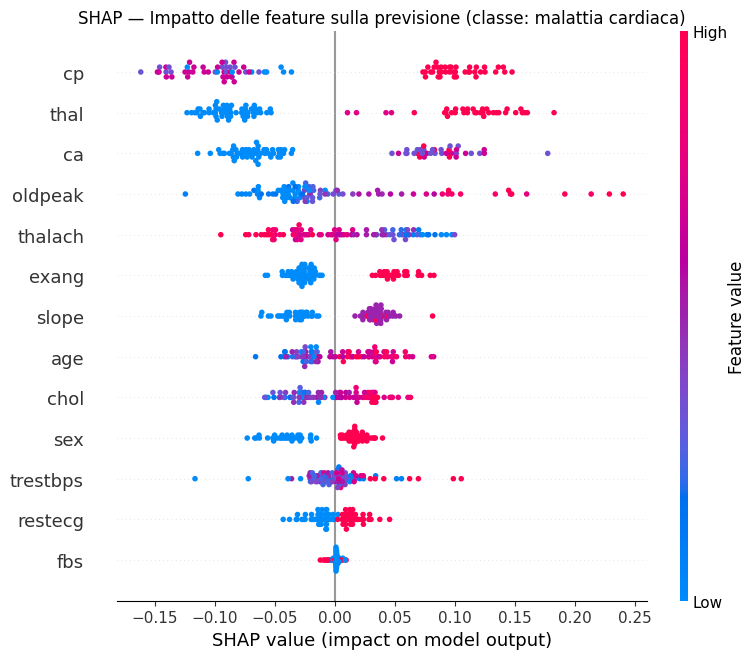

In [13]:
# Beeswarm plot: mostra la distribuzione e la direzione del contributo di ogni feature
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_test_sc, show=False)
plt.title("SHAP — Impatto delle feature sulla previsione (classe: malattia cardiaca)")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

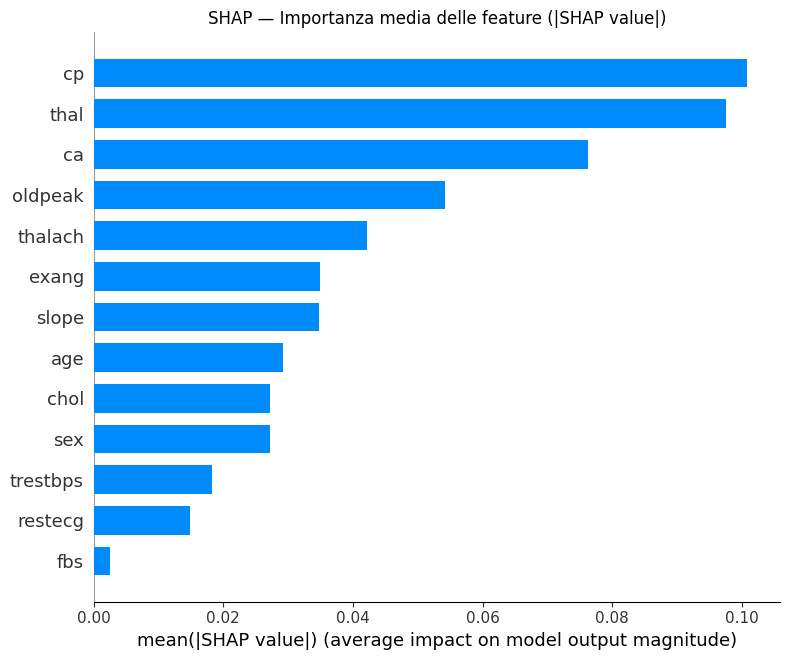

In [14]:
# Bar plot: importanza media assoluta dei valori SHAP per feature
plt.figure(figsize=(8, 5))
shap.summary_plot(sv, X_test_sc, plot_type="bar", show=False)
plt.title("SHAP — Importanza media delle feature (|SHAP value|)")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()